In [5]:
# Import necessary libraries
import optuna
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Pima Indian Diabetes dataset from sklearn
# Note: Scikit-learn's built-in 'load_diabetes' is a regression dataset.
# We will load the actual diabetes dataset from an external source
import pandas as pd

# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset
df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [41]:
import numpy as np

# Replace zero values with NaN in columns where zero is not a valid value
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_vals] = df[cols_with_missing_vals].replace(0, np.nan)

# Impute the missing values with the mean of the respective column
df.fillna(df.mean(), inplace=True)

# Check if there are any remaining missing values
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [43]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')


Training set shape: (537, 8)
Test set shape: (231, 8)


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [57]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters


[I 2026-08-12 22:45:13,435] A new study created in memory with name: no-name-4c0e3dd5-d6fe-4aa1-85d4-e693c86e6ded
[I 2026-08-12 22:45:15,961] Trial 0 finished with value: 0.7597765363128491 and parameters: {'n_estimators': 171, 'max_depth': 4}. Best is trial 0 with value: 0.7597765363128491.
[I 2026-08-12 22:45:17,699] Trial 1 finished with value: 0.7746741154562384 and parameters: {'n_estimators': 103, 'max_depth': 18}. Best is trial 1 with value: 0.7746741154562384.
[I 2026-08-12 22:45:20,390] Trial 2 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 163, 'max_depth': 14}. Best is trial 1 with value: 0.7746741154562384.
[I 2026-08-12 22:45:22,660] Trial 3 finished with value: 0.7746741154562384 and parameters: {'n_estimators': 159, 'max_depth': 16}. Best is trial 1 with value: 0.7746741154562384.
[I 2026-08-12 22:45:24,371] Trial 4 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 121, 'max_depth': 12}. Best is trial 1 with value: 0.77467

In [59]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7821229050279331
Best hyperparameters: {'n_estimators': 73, 'max_depth': 20}


In [61]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.75


## Samplers in Optuna

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize


In [25]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2026-08-12 22:27:06,105] A new study created in memory with name: no-name-46b11aeb-944d-483d-9e05-ed4de50e8f9c
[I 2026-08-12 22:27:08,165] Trial 0 finished with value: 0.7597765363128491 and parameters: {'n_estimators': 150, 'max_depth': 4}. Best is trial 0 with value: 0.7597765363128491.
[I 2026-08-12 22:27:10,120] Trial 1 finished with value: 0.7783985102420857 and parameters: {'n_estimators': 126, 'max_depth': 7}. Best is trial 1 with value: 0.7783985102420857.
[I 2026-08-12 22:27:11,208] Trial 2 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 71, 'max_depth': 11}. Best is trial 1 with value: 0.7783985102420857.
[I 2026-08-12 22:27:13,662] Trial 3 finished with value: 0.7765363128491621 and parameters: {'n_estimators': 164, 'max_depth': 16}. Best is trial 1 with value: 0.7783985102420857.
[I 2026-08-12 22:27:16,312] Trial 4 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 181, 'max_depth': 13}. Best is trial 1 with value: 0.7783985

In [29]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7802607076350093
Best hyperparameters: {'n_estimators': 121, 'max_depth': 19}


In [31]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.74


In [33]:
search_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20]
}

In [35]:
# Create a study and optimize it using GridSampler
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.GridSampler(search_space))
study.optimize(objective)

[I 2026-08-12 22:30:49,534] A new study created in memory with name: no-name-7ea0068b-a847-49f0-90cc-db164f300193
[I 2026-08-12 22:30:50,891] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-08-12 22:30:52,966] Trial 1 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 150, 'max_depth': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-08-12 22:30:53,652] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 50, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2026-08-12 22:30:54,922] Trial 3 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 100, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2026-08-12 22:30:56,211] Trial 4 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 20}. Best is trial 2 with value: 0.772811

In [37]:

# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7746741154562384
Best hyperparameters: {'n_estimators': 50, 'max_depth': 5}


In [39]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')


Test Accuracy with best hyperparameters: 0.74


## Optuna Visualizations

In [53]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

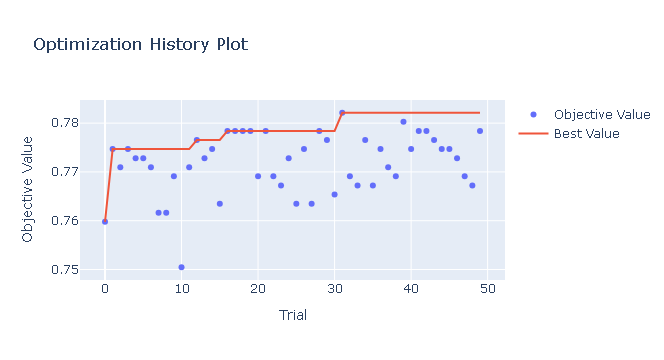

In [63]:
# 1. Optimization History
plot_optimization_history(study).show()

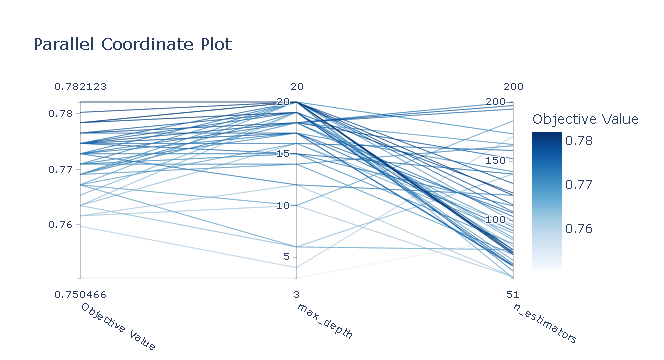

In [65]:
# 2. Parallel Coordinates Plot
plot_parallel_coordinate(study).show()

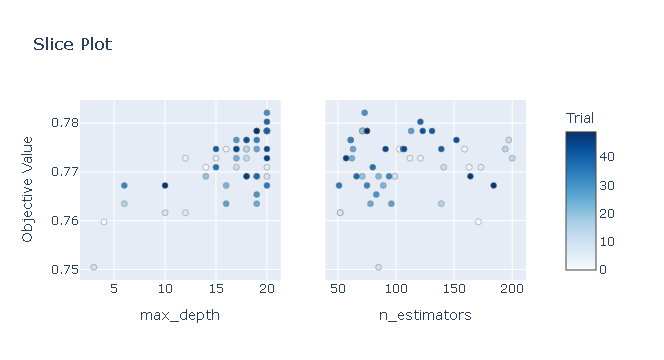

In [67]:
# 3. Slice Plot
plot_slice(study).show()

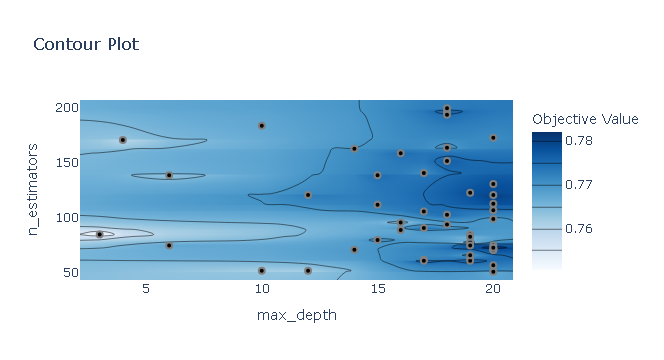

In [69]:
# 4. Contour Plot
plot_contour(study).show()

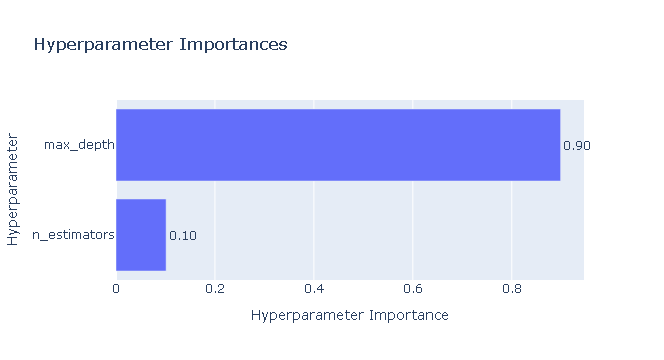

In [71]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

## Optimizing Multiple ML Models

In [77]:
# Importing the required libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [79]:
# Define the objective function for Optuna
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical('classifier', ['SVM', 'RandomForest', 'GradientBoosting'])

    if classifier_name == 'SVM':
        # SVM hyperparameters
        c = trial.suggest_float('C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

        model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)

    elif classifier_name == 'RandomForest':
        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    elif classifier_name == 'GradientBoosting':
        # Gradient Boosting hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [81]:
# Create a study and optimize it using CmaEsSampler
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-08-12 23:12:07,454] A new study created in memory with name: no-name-02ca3999-f81b-4c2d-9683-72ddb4db56bf
[I 2026-08-12 23:12:07,639] Trial 0 finished with value: 0.6871508379888268 and parameters: {'classifier': 'SVM', 'C': 21.96597774089639, 'kernel': 'sigmoid', 'gamma': 'scale'}. Best is trial 0 with value: 0.6871508379888268.
[I 2026-08-12 23:12:10,712] Trial 1 finished with value: 0.7504655493482307 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 201, 'learning_rate': 0.27257116916157864, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.7504655493482307.
[I 2026-08-12 23:12:13,137] Trial 2 finished with value: 0.7653631284916201 and parameters: {'classifier': 'RandomForest', 'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}. Best is trial 2 with value: 0.7653631284916201.
[I 2026-08-12 23:12:13,217] Trial 3 finished with value: 0.7672253258845437 and paramet

In [83]:
# Retrieve the best trial
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'classifier': 'SVM', 'C': 0.12297018874389057, 'kernel': 'linear', 'gamma': 'auto'}
Best trial accuracy: 0.7895716945996275


In [85]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_gamma,params_kernel,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
0,0,0.687151,2026-08-12 23:12:07.464864,2026-08-12 23:12:07.639462,0 days 00:00:00.174598,21.965978,NaN,SVM,scale,sigmoid,NaN,NaN,NaN,NaN,NaN,COMPLETE
1,1,0.750466,2026-08-12 23:12:07.642903,2026-08-12 23:12:10.712661,0 days 00:00:03.069758,NaN,NaN,GradientBoosting,NaN,NaN,0.272571,5.0,6.0,3.0,201.0,COMPLETE
2,2,0.765363,2026-08-12 23:12:10.713670,2026-08-12 23:12:13.137364,0 days 00:00:02.423694,NaN,True,RandomForest,NaN,NaN,NaN,5.0,1.0,3.0,150.0,COMPLETE
3,3,0.767225,2026-08-12 23:12:13.139459,2026-08-12 23:12:13.217086,0 days 00:00:00.077627,0.288354,NaN,SVM,auto,sigmoid,NaN,NaN,NaN,NaN,NaN,COMPLETE
4,4,0.728119,2026-08-12 23:12:13.217086,2026-08-12 23:12:18.823601,0 days 00:00:05.606515,NaN,NaN,GradientBoosting,NaN,NaN,0.040801,19.0,1.0,9.0,149.0,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.787709,2026-08-12 23:13:14.010852,2026-08-12 23:13:14.070890,0 days 00:00:00.060038,0.167362,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
96,96,0.785847,2026-08-12 23:13:14.079064,2026-08-12 23:13:14.225134,0 days 00:00:00.146070,9.044012,NaN,SVM,auto,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
97,97,0.785847,2026-08-12 23:13:14.227245,2026-08-12 23:13:14.299783,0 days 00:00:00.072538,0.238740,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,COMPLETE
98,98,0.765363,2026-08-12 23:13:14.300844,2026-08-12 23:13:14.372587,0 days 00:00:00.071743,0.102743,NaN,SVM,scale,sigmoid,NaN,NaN,NaN,NaN,NaN,COMPLETE


In [87]:
study.trials_dataframe()['params_classifier'].value_counts()

params_classifier
SVM                 80
GradientBoosting    10
RandomForest        10
Name: count, dtype: int64

In [89]:
study.trials_dataframe().groupby('params_classifier')['value'].mean()

params_classifier
GradientBoosting    0.748417
RandomForest        0.765363
SVM                 0.775978
Name: value, dtype: float64

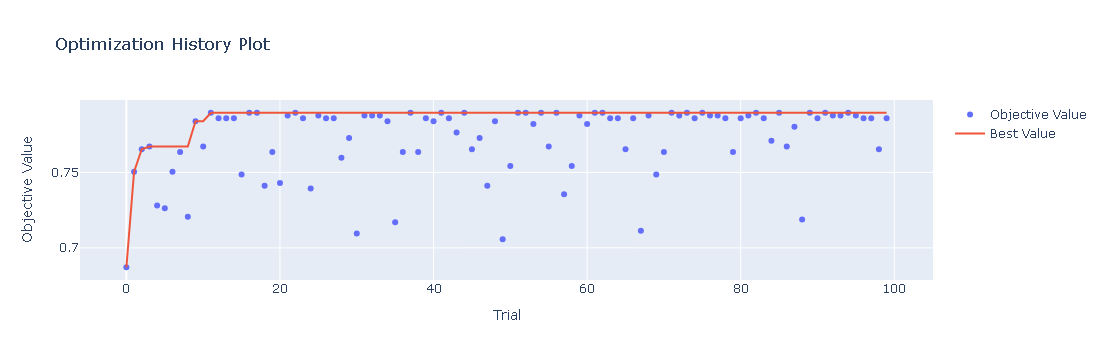

In [91]:
# 1. Optimization History
plot_optimization_history(study).show()

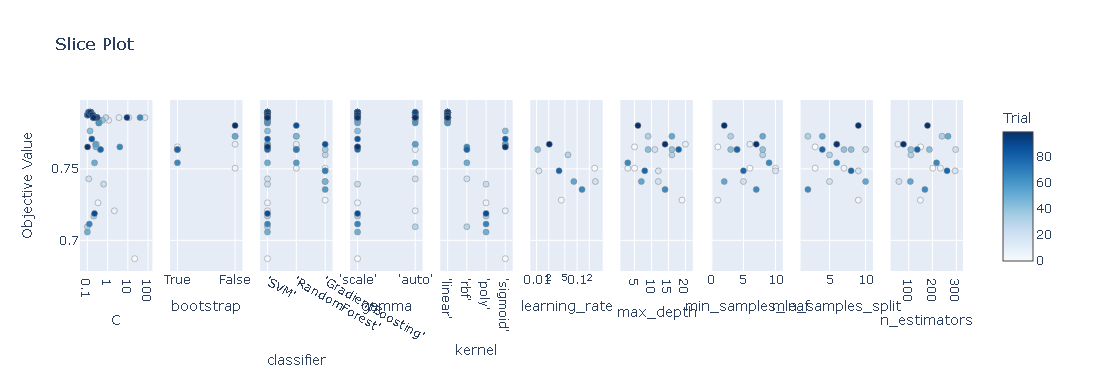

In [93]:
# 3. Slice Plot
plot_slice(study).show()

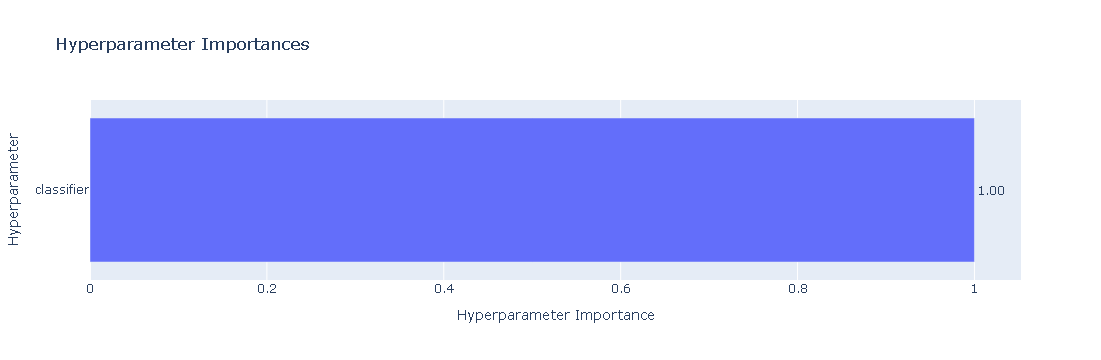

In [95]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

In [97]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import numpy as np

# Load the Iris dataset
X, y = load_iris(return_X_y=True)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the objective function for XGBoost
def objective(trial):
    # Hyperparameter search space
    param = {
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',  # Ensure that the eval_metric is specified here
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'n_estimators': 300,
    }

    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # Define a pruning callback based on evaluation metrics
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "eval-mlogloss")  # Match the metric name in the evals list

    # Train the model
    bst = xgb.train(
        param,
        dtrain,
        num_boost_round=300,
        evals=[(dtrain, "train"), (dtest, "eval")],  # Ensure the eval datasets and names are specified
        early_stopping_rounds=30,
        callbacks=[pruning_callback]
    )

    # Predict on the test set
    preds = bst.predict(dtest)
    best_preds = [int(np.argmax(line)) for line in preds]

    # Return accuracy as the objective value
    accuracy = accuracy_score(y_test, best_preds)
    return accuracy

# Create a study with pruning
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.SuccessiveHalvingPruner())
study.optimize(objective, n_trials=50)

# Output the best trial
print(f"Best trial: {study.best_trial.params}")
print(f"Best accuracy: {study.best_value}")


[I 2026-08-12 23:28:48,933] A new study created in memory with name: no-name-3b23523c-ab72-4edb-84d9-108e601dc948


[0]	train-mlogloss:0.96716	eval-mlogloss:0.96317
[1]	train-mlogloss:0.83887	eval-mlogloss:0.83230
[2]	train-mlogloss:0.78535	eval-mlogloss:0.78135
[3]	train-mlogloss:0.74033	eval-mlogloss:0.74005
[4]	train-mlogloss:0.66845	eval-mlogloss:0.66494
[5]	train-mlogloss:0.63519	eval-mlogloss:0.62871
[6]	train-mlogloss:0.56534	eval-mlogloss:0.55023
[7]	train-mlogloss:0.53407	eval-mlogloss:0.51652


C:\Users\Nandika\anaconda3\Lib\importlib\__init__.py:90: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


[8]	train-mlogloss:0.49688	eval-mlogloss:0.47637
[9]	train-mlogloss:0.45927	eval-mlogloss:0.43487
[10]	train-mlogloss:0.45461	eval-mlogloss:0.43247
[11]	train-mlogloss:0.42274	eval-mlogloss:0.39570
[12]	train-mlogloss:0.40591	eval-mlogloss:0.37828
[13]	train-mlogloss:0.38007	eval-mlogloss:0.35035
[14]	train-mlogloss:0.36660	eval-mlogloss:0.33372
[15]	train-mlogloss:0.35245	eval-mlogloss:0.31871
[16]	train-mlogloss:0.33806	eval-mlogloss:0.30261
[17]	train-mlogloss:0.33754	eval-mlogloss:0.30227
[18]	train-mlogloss:0.32597	eval-mlogloss:0.28970
[19]	train-mlogloss:0.31539	eval-mlogloss:0.27617
[20]	train-mlogloss:0.29937	eval-mlogloss:0.25776
[21]	train-mlogloss:0.29181	eval-mlogloss:0.25081
[22]	train-mlogloss:0.28297	eval-mlogloss:0.23895
[23]	train-mlogloss:0.27400	eval-mlogloss:0.22866
[24]	train-mlogloss:0.26762	eval-mlogloss:0.22164
[25]	train-mlogloss:0.26140	eval-mlogloss:0.21381
[26]	train-mlogloss:0.25561	eval-mlogloss:0.20684
[27]	train-mlogloss:0.25541	eval-mlogloss:0.20664
[2

[I 2026-08-12 23:28:52,716] Trial 0 finished with value: 1.0 and parameters: {'lambda': 0.0013417322811386445, 'alpha': 8.467630590006121e-06, 'eta': 0.12706423000073042, 'gamma': 3.386504676644361e-06, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.6960281383845042, 'colsample_bytree': 0.49429610114248673}. Best is trial 0 with value: 1.0.


...

[0]	train-mlogloss:1.00373	eval-mlogloss:0.99899
[1]	train-mlogloss:0.93304	eval-mlogloss:0.93016


[I 2026-08-12 23:29:15,757] Trial 48 pruned. Trial was pruned at iteration 2.


[0]	train-mlogloss:0.90835	eval-mlogloss:0.89745
[1]	train-mlogloss:0.76133	eval-mlogloss:0.74445


[I 2026-08-12 23:29:15,891] Trial 49 pruned. Trial was pruned at iteration 2.


Best trial: {'lambda': 0.0013417322811386445, 'alpha': 8.467630590006121e-06, 'eta': 0.12706423000073042, 'gamma': 3.386504676644361e-06, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.6960281383845042, 'colsample_bytree': 0.49429610114248673}
Best accuracy: 1.0


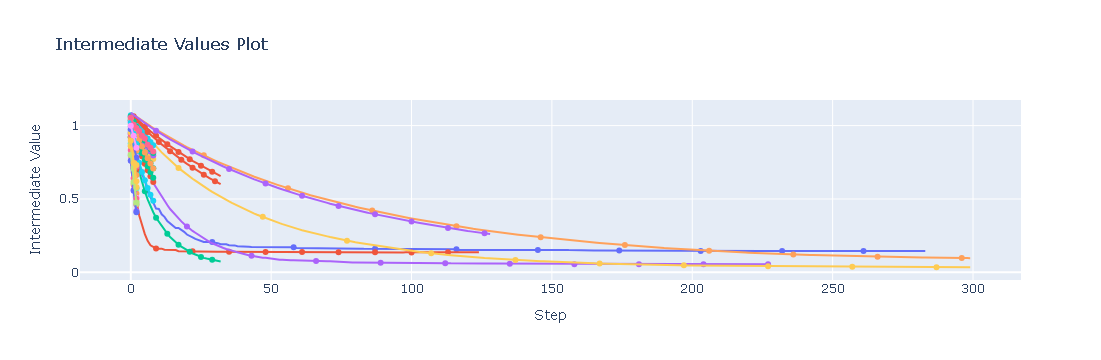

In [99]:
from optuna.visualization import plot_intermediate_values

# 1. Plot intermediate values during the trials
plot_intermediate_values(study).show()